# 01 - Data Curation
Download and explore PHI-base data, filter and clean sequences, export processed dataset.

## GoHREP:

**Goal:**

Curate a clean, non-redundant dataset of pathogen virulence gene sequences from PHI-base, mapped to 8 functional class categories, and exported as model-agnostic CSV splits ready for ESM-2 fine-tuning.

**Hypothesis:**

Systematically filtering biological noise, removing redundant sequences, and mapping free-text annotations to biologically coherent functional classes will prevent model memorisation and enable ESM-2 to learn generalised sequence features associated with the functional classes of pathogen virulence genes.

**Rationale:**

PHI-base catalogues experimentally verified virulence genes across a broad range of fungal, oomycete, and bacterial pathogens, spanning effectors, transcription factors, kinases, proteases, transporters, and other proteins that contribute to infection. These functional classes are largely determined by sequence through conserved catalytic residues, domain architecture, and structural motifs, making them a more appropriate classification target for sequence-only models than virulence outcome, which is inherently relational (dependent on both the pathogen gene and the specific host context).

High-quality input data is necessary for effective parameter-efficient fine-tuning. PHI-base is phenotype-centric rather than gene-centric, meaning the same gene can appear multiple times across different host experiments and mutant phenotypes — deduplication to one row per unique gene is therefore a prerequisite before any downstream analysis. Removing fragments, low-complexity sequences, and highly redundant clusters ensures the model learns biological signals rather than dataset artefacts. Stratified splitting preserves functional class proportions in the hold-out test set, and deferring tokenization to downstream notebooks keeps the curation pipeline model-agnostic.

**Experimental Plan:**

1. **Source acquisition:** Download the most recent PHI-base metadata CSV and corresponding sequence FASTA files directly from the PHI-base GitHub repository.
2. **Parsing and target mapping:** Merge sequence data with metadata using PHI-base accession IDs as keys. Consolidate 4,137 unique free-text Function annotations into 8 biologically meaningful functional classes using a keyword-based mapping, validated by systematic literature review.
3. **Deduplication:** Collapse the phenotype-centric PHI-base records to one row per unique gene, removing entries with conflicting functional class labels across experiments.
4. **Biological quality control:** Filter sequences by length (50–1,500 aa), remove sequences with any ambiguous residues (X), and filter out low-complexity sequences with poly-X runs ≥10 or single amino acid fraction >35%.
5. **Redundancy reduction:** Cluster the filtered sequences using MMseqs2 at 90% sequence identity and 80% target coverage. Retain only cluster representatives to prevent data leakage and memorisation. Justify the identity threshold empirically by comparing retention across 70%, 80%, 90%, and 95% thresholds.
6. **Dataset characterisation:** Visualise final class distributions, sequence length profiles, within-class sequence diversity, and flag cross-class high-identity pairs (≥80%) for downstream error analysis.
7. **Splitting and export:** Perform a stratified train/test split (90/10), preserving functional class proportions. Export raw sequence CSV splits to `data/splits/`. Tokenization and train/validation fold generation are deferred to the prototyping and fine-tuning notebooks.

# 0 Environment Setup

This section mounts Google Drive and installs dependencies from the GitHub repository.

In [1]:
import yaml
from google.colab import drive
import os

drive.mount('/content/drive')
PROJECT_ROOT = "/content/drive/MyDrive/esm-phi-effector"
os.chdir(PROJECT_ROOT)

config_path = os.path.join(PROJECT_ROOT, "configs/data_config.yaml")
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

Mounted at /content/drive


In [2]:
!apt-get install -y mmseqs2 # not pip installable

if os.path.exists("requirements.txt"):
    !pip install -r requirements.txt

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libgzstream0
The following NEW packages will be installed:
  libgzstream0 mmseqs2
0 upgraded, 2 newly installed, 0 to remove and 37 not upgraded.
Need to get 7,403 kB of archives.
After this operation, 33.5 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libgzstream0 amd64 1.5+git20171107.9a20658-1 [7,410 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 mmseqs2 amd64 13-45111+ds-2 [7,396 kB]
Fetched 7,403 kB in 3s (2,856 kB/s)
Selecting previously unselected package libgzstream0:amd64.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack .../libgzstream0_1.5+git20171107.9a20658-1_amd64.deb ...
Unpacking libgzstream0:amd64 (1.5+git20171107.9a20658-1) ...
Selecting previously unselected package mmseqs2.
Preparing to unpack .../mmseq

In [3]:
import pandas as pd
from Bio import SeqIO
import shutil
import subprocess
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import re
from torch.utils.data import Dataset
import numpy as np

# 1 Data Acquisition

This section mounts Google Drive, creates the project directory structure (if it doesn't already exist), and downloads the current release of the PHI-base dataset

Sources:

- Metadata: phi-base_current.csv (Mutant phenotypes and protein IDs)
- Sequences: phi-base_current.fas (Fasta sequences for the associated proteins)
- Citation: Urban et al., 2025 "PHI-base – the multi-species pathogen–host interaction database in 2025" doi.org/10.1093/nar/gkae1084

In [4]:
raw_dir = config['paths']['raw_dir']
os.makedirs(raw_dir, exist_ok=True)

files = {
    config['paths']['metadata_file']: "https://raw.githubusercontent.com/PHI-base/data/master/releases/phi-base_current.csv",
    config['paths']['fasta_file']: "https://raw.githubusercontent.com/PHI-base/data/master/releases/phi-base_current.fas"
}

for name, url in files.items():
    file_path = os.path.join(raw_dir, name)
    if not os.path.exists(file_path):
        !wget -O {file_path} {url}

# 2 Metadata and Sequence Merging

This section loads the PHI-base metadata and FASTA sequences, then merges them into a single DataFrame using the PHI-base Accession IDs as keys.

In [5]:
# Load metadata
raw_dir = config['paths']['raw_dir']
metadata_path = os.path.join(raw_dir, config['paths']['metadata_file'])
fasta_path = os.path.join(raw_dir, config['paths']['fasta_file'])
metadata = pd.read_csv(metadata_path, low_memory=False)

# Parse sequences: Extract 'PHI:XXXX' from the middle of the complex header
sequences = {}
for record in SeqIO.parse(fasta_path, "fasta"):
    # Split header by '#' and find the part starting with 'PHI:'
    parts = record.id.split('#')
    phi_id = next((p for p in parts if p.startswith('PHI:')), None)
    if phi_id:
        sequences[phi_id] = str(record.seq)

# Map sequences using the extracted PHI IDs
metadata['sequence'] = metadata['PHI_MolConn_ID'].map(sequences)

# Remove entries without corresponding sequence data
df_raw = metadata.dropna(subset=['sequence']).copy()
df_raw['seq_length'] = df_raw['sequence'].apply(len)

print(f"Total records successfully merged: {len(df_raw)}")
print(f"Unique PHI accession IDs: {df_raw['PHI_MolConn_ID'].nunique()}")
print(f"Unique sequences: {df_raw['sequence'].nunique()}")
print(f"Duplicate sequences (same sequence, different accession): {len(df_raw) - df_raw['sequence'].nunique()}")

Total records successfully merged: 14028
Unique PHI accession IDs: 8662
Unique sequences: 8536
Duplicate sequences (same sequence, different accession): 5492


PHI-base is phenotype-centric, not gene-centric. Genes can be associated with multiple experiments, hosts, or mutant phenotypes, which is why there are more records than there are unique sequences.

# 2.2 Defining and mapping functional classes

Before defining classes, I'll first explore the `Function` column to understand its structure and determine the best strategy for creating a tractable label set.

In [6]:
# How many unique functional annotations are there?
print(f"Total unique Function values: {df_raw['Function'].nunique()}")
print(f"Missing Function annotations: {df_raw['Function'].isna().sum()}")
print(f"Coverage: {df_raw['Function'].notna().sum()} / {len(df_raw)} ({df_raw['Function'].notna().sum()/len(df_raw)*100:.1f}%)")

Total unique Function values: 4137
Missing Function annotations: 181
Coverage: 13847 / 14028 (98.7%)


Very few of the genes are missing functional annotations (1.3%). This is a good sign. However, there are an incredibly large number of Function values. This won't be appropriate for my classifier.

**Strategy 1: Filter by minimum frequency**

The simplest approach would be to keep only Function values that appear at least N times. How much data is retained at each threshold?

In [7]:
# How much data is retained at different frequency thresholds?
func_counts = df_raw['Function'].value_counts()

print(f"{'Min sequences':<20} {'Classes':<15} {'Sequences retained':<25} {'% retained':<15}")
print("-" * 75)
for threshold in [5, 10, 20, 50, 100]:
    surviving_classes = (func_counts >= threshold).sum()
    surviving_seqs = func_counts[func_counts >= threshold].sum()
    print(f"{threshold:<20} {surviving_classes:<15} {surviving_seqs:<25} {surviving_seqs/len(df_raw)*100:.1f}%")

Min sequences        Classes         Sequences retained        % retained     
---------------------------------------------------------------------------
5                    473             7762                      55.3%
10                   177             5814                      41.4%
20                   54              4210                      30.0%
50                   14              3026                      21.6%
100                  8               2597                      18.5%


Filtering by frequency alone results in poor data retention - even at a threshold of just 5 sequences per class, 45% of data is discarded, and the number of classes (473) remains far too large for a classification task. This approach is therefore unsuitable.

**Strategy 2: Keyword-based Mapping to Broad Biochemical Classes**

Instead, I will use Claude Opus 4.6 (Extended Thinking) to examine the most frequently annotated Function values to identify natural groupings that could be captured by keyword matching. This approach should retain far more sequences while producing a tractable number of meaningful classes:

In [8]:
# Examine all Function values with at least 10 sequences to inform keyword groupings
func_counts = df_raw['Function'].value_counts()
print(f"Function values with >= 10 sequences ({(func_counts >= 10).sum()} total):\n")
print(func_counts[func_counts >= 10].to_string())

Function values with >= 10 sequences (177 total):

Function
effector protein                                                                                               926
transcription factor                                                                                           788
Zn2Cys6 transcription factor                                                                                   184
hypothetical protein                                                                                           173
type VI secretion system protein                                                                               166
type III effectors (T3E) and T3E-like genes                                                                    142
protein kinase                                                                                                 118
cell surface-associated aspartyl protease (yapsins)                                                            100
transcriptional regu

### Functional class mapping

#### Strategy

I gave these annotations to Claude to review. It identified natural groupings based on biochemical function. An initial keyword-to-class mapping was generated by Claude Sonnet 4. This was subjected to systematic review using Claude Opus 4.6 (Extended Thinking). Every keyword was evaluated individually against the PHI-base annotation frequency distribution and peer-reviewed literature. This review identified several misclassifications in the mapping that would have introduced label noise into the training data.

The full keyword-by-keyword review with confidence ratings and literature citations is available in [Supplementary File: `https://github.com/joshuandwilliams/esm-phi-effector/tree/main/docs/PHI-base Functional Class Keyword Review.md`].

#### Groupings

These groupings are appropriate for sequence-only classification because each class has distinct sequence-level signatures that ESM-2 embeddings can capture:

| Class | Rationale | Example annotations |
|---|---|---|
| **Effector** | Secreted virulence proteins with host-targeting domains | effector protein, type III effector, TAL-effector, plant avirulence determinant, dense granule protein |
| **Secretion system** | Structural components of protein secretion machineries | type VI secretion system, type III secretion, autotransporter, Sec-independent protein translocase |
| **Transcription factor / Regulator** | DNA-binding and chromatin-modifying regulators of gene expression | transcription factor, Zn2Cys6, bZip, response regulator, sigma factor, histone deacetylase, DNA methyltransferase |
| **Protease** | Defined by catalytic residues and substrate-binding pockets | serine protease, cysteine protease, aspartyl protease, subtilisin-like, calpain, metalloproteinase |
| **Kinase / Signalling** | Nucleotide-binding, phosphotransfer, and signal transduction domains | protein kinase, MAP kinase, GPCR, phosphodiesterase, NADPH oxidase, F-box protein |
| **Cell wall / Carbohydrate-active** | CAZy family enzymes with carbohydrate-binding and catalytic domains | chitin synthase, xylanase, pectate lyase, glycoside hydrolase, trehalase, cutinase |
| **Transporter / Membrane** | Transmembrane helices and substrate-binding domains | ABC transporter, efflux pump, outer membrane protein, Ca2+ pump, divalent metal transporter |
| **Secondary metabolite / Biosynthesis** | Large multi-domain enzyme complexes for specialised metabolism | polyketide synthase, NRPS, phenazine biosynthesis, enniatin synthase, siderophore biosynthesis |

Entries annotated as hypothetical, uncharacterised, or unknown are dropped as they carry no functional signal for the model to learn. A small number of "putative" annotations with unambiguous domain architecture (e.g. "putative transcription factor") are recovered before filtering.

In [9]:
def map_functional_class(func):
    """
    Map free-text PHI-base Function annotations to broad biochemical classes
    using keyword matching. Returns None for unknown/hypothetical entries,
    which are subsequently dropped.
    """
    if pd.isna(func):
        return None

    func_lower = func.lower()

    # ── Handle recoverable putative annotations before the unknown filter ──
    putative_recoverable = [
        'putative transcription factor', 'putative transcriptional regulator'
    ]
    if any(k in func_lower for k in putative_recoverable):
        return 'Transcription factor / Regulator'

    # ── Unknown / hypothetical → drop ──
    unknown_keywords = [
        'hypothetical', 'uncharacterized', 'uncharacterised', 'unknown',
        'conserved hypothetical', 'putative'
    ]
    if any(k in func_lower for k in unknown_keywords):
        return None

    # ── Secretion system — apparatus that enables effector delivery ──
    secretion_keywords = [
        'type vi secretion', 'type iii secretion', 'type iv pili',
        'secretion system', 'sec-independent', 'protein translocase',
        'autotransporter'
    ]
    if any(k in func_lower for k in secretion_keywords):
        return 'Secretion system'

    # ── Effector — secreted virulence/avirulence proteins ──
    effector_keywords = [
        'effector', 'avirulence', 'avr', 'tal-effector', 'tal effector',
        'type iii effector', 't3e', 'secreted effector', 'dense granule',
        'host-selective toxin', 'virulence factor'
    ]
    if any(k in func_lower for k in effector_keywords):
        return 'Effector'

    # ── Transcription factor / Regulator ──
    tf_keywords = [
        'transcription factor', 'transcriptional regulator', 'transcriptional repressor',
        'transcription regulator', 'transcriptional regulatory', 'dna-binding',
        'zn2cys6', 'bzip', 'b-zip', 'lysr',
        'response regulator', 'two-component', 'regulatory protein',
        'sigma factor', 'rna polymerase sigma', 'alternative sigma',
        'regulatory system', 'regulator',
        'histone deacetylase', 'histone acetyltransferase',
        'dna methyltransferase',  # epigenetic regulation of transcription
        'mediator subunit'         # transcription co-activator complex
    ]
    if any(k in func_lower for k in tf_keywords):
        return 'Transcription factor / Regulator'

    # ── Protease ──
    protease_keywords = [
        'protease', 'proteinase', 'peptidase', 'subtilisin', 'staphopain',
        'cysteine protease', 'serine protease', 'aspartyl protease',
        'metalloproteinase', 'metalloprotease',  # fixed from 'metalloprotein'
        'endoprotease', 'glutamyl endopeptidase',
        'calpain',
        'signal peptidase', 'lipoprotein signal peptidase'  # SPase family serine proteases
    ]
    if any(k in func_lower for k in protease_keywords):
        return 'Protease'

    # ── Kinase / Signalling ──
    kinase_keywords = [
        'kinase', 'phosphatase', 'phosphodiesterase', 'phospholipase',
        'gpcr', 'g-protein', 'g protein', 'g alpha',
        'map kinase', 'mapk', 'mitogen-activated',
        'adenylate cyclase', 'diguanylate cyclase',
        'quorum sensing', 'chemotaxis',
        'autophagy',          # ATG1 is a kinase; regulated by TOR signalling
        'nadph oxidase',      # ROS signalling enzyme
        'catalase',           # ROS detoxification / oxidative stress signalling
        'superoxide dismutase',  # antioxidant enzyme
        'f-box',              # SCF E3 ubiquitin ligase signalling component
        'ubiquitin ligase',   # protein turnover in signalling
        'gtpase',             # GTPase signalling (Rho, Ras family)
    ]
    if any(k in func_lower for k in kinase_keywords):
        return 'Kinase / Signalling'

    # ── Cell wall / Carbohydrate-active ──
    cw_keywords = [
        'chitin', 'xylanase', 'xylan', 'pectate', 'polygalacturonase',
        'glucan', 'glucanase', 'glucanosyltransferase', 'chitinase',
        'glycoside hydrolase', 'glycosyltransfer', 'mannosyltransfer',
        'cell wall', 'carbohydrate', 'beta-1,3', 'beta-1,4',
        'transglycosylase', 'cutinase', 'cellulose', 'amidase',
        'trehalase'
    ]
    if any(k in func_lower for k in cw_keywords):
        return 'Cell wall / Carbohydrate-active'

    # ── Transporter / Membrane ──
    transporter_keywords = [
        'transporter', 'transport', 'efflux pump', 'outer membrane',
        'membrane protein', 'permease', 'ca2+', 'ion channel',
        'abc transporter', 'sugar transporter', 'zinc transporter',
        'divalent metal',
        'cell envelope'  # cell surface proteins
    ]
    if any(k in func_lower for k in transporter_keywords):
        return 'Transporter / Membrane'

    # ── Secondary metabolite / Biosynthesis ──
    sm_keywords = [
        'polyketide', 'non-ribosomal peptide', 'nrps', 'phenazine',
        'fusaric', 'mycotoxin', 'biosynthesis', 'synthetase',
        'secondary metabolite', 'enniatin',
        'methyltransferase', 'acetyltransferase',
        'siderophore', 'aerobactin', 'bacillibactin',  # siderophore biosynthesis
        'salicylate hydroxylase'  # degrades plant defence metabolite SA
    ]
    if any(k in func_lower for k in sm_keywords):
        return 'Secondary metabolite / Biosynthesis'

    # Could not map to any class
    return None


# Apply mapping
df_raw['functional_class'] = df_raw['Function'].apply(map_functional_class)

# Report mapping outcome
total = len(df_raw)
mapped = df_raw['functional_class'].notna().sum()
unmapped = df_raw['functional_class'].isna().sum()

print(f"Total sequences:   {total}")
print(f"Successfully mapped: {mapped} ({mapped/total*100:.1f}%)")
print(f"Dropped (unmapped):  {unmapped} ({unmapped/total*100:.1f}%)")
print(f"\nClass distribution:")
print(df_raw['functional_class'].value_counts())

Total sequences:   14028
Successfully mapped: 8290 (59.1%)
Dropped (unmapped):  5738 (40.9%)

Class distribution:
functional_class
Transcription factor / Regulator       2207
Kinase / Signalling                    1732
Effector                               1490
Transporter / Membrane                  691
Cell wall / Carbohydrate-active         599
Secondary metabolite / Biosynthesis     563
Protease                                551
Secretion system                        457
Name: count, dtype: int64


Almost 60% of sequences are retained in 8 classes. This is a far better solution than the class size thresholds proposed previously.

Class distribution is unbalanced, but not catastrophically so. Transcription factor / Regulator (2,207) is roughly 5x Secretion system (457), which is manageable with stratified splitting and weight loss. This imbalance reflects the biology of PHI-base rather than a mapping artefact.

In [10]:
# What are we dropping? Check the most common unmapped Function values
unmapped = df_raw[df_raw['functional_class'].isna() & df_raw['Function'].notna()]
print(f"Unmapped but annotated (potentially recoverable): {len(unmapped)}")
print(f"Truly missing Function annotation: {df_raw['Function'].isna().sum()}\n")
print("Most common unmapped Function values:")
print(unmapped['Function'].value_counts().head(30).to_string())

Unmapped but annotated (potentially recoverable): 5557
Truly missing Function annotation: 181

Most common unmapped Function values:
Function
hypothetical protein                                              173
uncharacterized protein                                            71
conserved hypothetical protein                                     49
cold shock protein                                                 40
Na(+)-translocating NADH-quinone reductase                         30
unknown                                                            29
NAD(P)-binding domain protein                                      21
endocarditis specific antigen                                      19
flagellin                                                          18
putative short chain dehydrogenase                                 18
phage-shock protein                                                18
dicer-like protein                                                 16
uncharacterised pr

Most of the drop is working as intended. The top entries are genuinely unclassifiable (hypothetical, uncharacterised, unknown = ~350 sequences correctly discarded).

Some additional things may be worth recovering, but this sort of specific detail isn't required at this time.

Of the remaining categories, many are broad oxidoreductase keywords which were removed from the Secondary metabolite class (e.g. NADH dehydrogenase)

# 2.3 Deduplication

PHI-base is phenotype-centric: the same gene can appear multiple times across different host experiments, mutant phenotypes, or pathosystems. Before visualisation and QC, redundant rows are collapsed to one row per unique gene. Genes with conflicting functional class labels across rows are removed first, as these represent genuine annotation ambiguity that would introduce label noise.

In [11]:
# Filter to mapped sequences only
df_mapped = df_raw[df_raw['functional_class'].notna()].copy()
print(f"Starting with mapped sequences: {len(df_mapped)}")

# 1. Remove genes with conflicting functional class labels
overlap_counts = df_mapped.groupby('PHI_MolConn_ID')['functional_class'].nunique()
conflicting_genes = overlap_counts[overlap_counts > 1].index
conflicting_rows = df_mapped['PHI_MolConn_ID'].isin(conflicting_genes)

print(f"Rows with conflicting functional class labels removed: {conflicting_rows.sum()}")
df_mapped = df_mapped[~conflicting_rows].copy()

# 2. Remove redundant rows (same gene, same class, different host/phenotype)
unique_genes = df_mapped['PHI_MolConn_ID'].nunique()
redundant_rows = len(df_mapped) - unique_genes

print(f"Redundant rows removed: {redundant_rows}")
df_mapped = df_mapped.sample(frac=1, random_state=config['splitting']['random_seed']).drop_duplicates(subset=['PHI_MolConn_ID'], keep='first')

# 3. Verify all genes are now unique
print(f"Deduplicated dataset size: {len(df_mapped)}")
assert len(df_mapped) == df_mapped['PHI_MolConn_ID'].nunique(), "Deduplication failed: duplicate PHI IDs remain"
print(f"All genes unique: True")

print(f"\nClass distribution after deduplication:")
print(df_mapped['functional_class'].value_counts())

Starting with mapped sequences: 8290
Rows with conflicting functional class labels removed: 31
Redundant rows removed: 3215
Deduplicated dataset size: 5044
All genes unique: True

Class distribution after deduplication:
functional_class
Transcription factor / Regulator       1668
Kinase / Signalling                    1157
Effector                                723
Transporter / Membrane                  395
Secondary metabolite / Biosynthesis     333
Cell wall / Carbohydrate-active         311
Secretion system                        245
Protease                                212
Name: count, dtype: int64


The deduplication removed 3,215 redundant rows (around 39% of mapped sequences), confirming how heavily PHI-base overrepresents well-studied gene-host systems across multiple experimental contexts. Only 31 rows were lost due to conflicting labels, suggesting the keyword mapping is largely internally consistent.

The class imbalances are preserved from the raw counts. Transcription factor / Regulator (1,668) remains the largest class at roughly 8x Protease (212), the smallest.

# 2.4 Initial Dataset Visualisation

This section visualises the raw mapped dataset prior to any quality filtering. The goal is to characterise the functional class distribution, identify class imbalances, understand sequence length variation across classes, and flag extreme outliers that would distort downstream QC thresholds. These plots inform the filtering decisions made in Section 3.

**Plot 1: Included vs Excluded Annotations by Frequency**

Justifies the keyword-based mapping strategy by showing where excluded annotations sit in the frequency distribution. If the keyword approach is working correctly, excluded annotations should be concentrated in the low-frequency bins where individual unique terms appear only once or a few times — i.e. the long tail of idiosyncratic free-text entries.

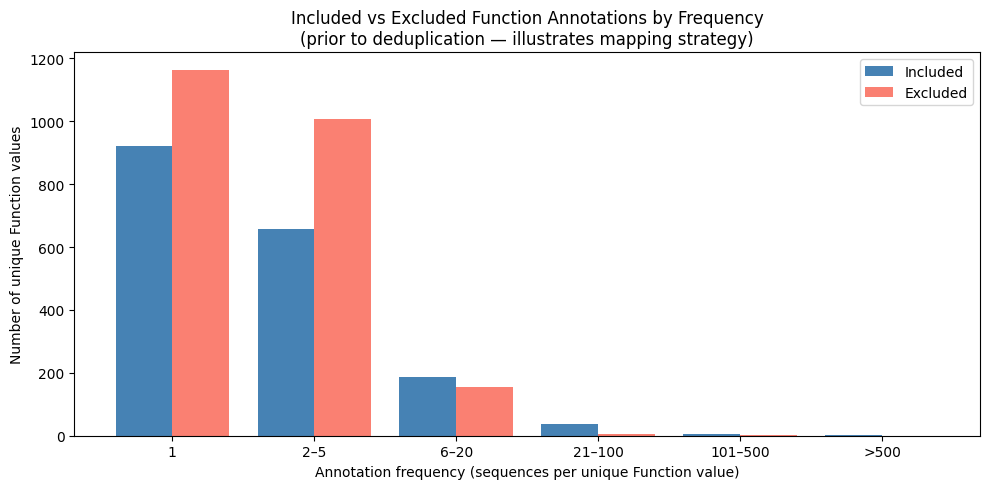

Included unique Function values: 1807
Excluded unique Function values: 2330


In [12]:
func_counts = df_raw['Function'].value_counts()
mapped_mask = df_raw['Function'].isin(
    df_raw[df_raw['functional_class'].notna()]['Function'].unique()
)

included_counts = df_raw[df_raw['functional_class'].notna()]['Function'].value_counts()
excluded_counts = df_raw[df_raw['functional_class'].isna() & df_raw['Function'].notna()]['Function'].value_counts()

# Bin by frequency for readability
def bin_counts(counts):
    bins = {'1': 0, '2–5': 0, '6–20': 0, '21–100': 0, '101–500': 0, '>500': 0}
    for v in counts:
        if v == 1: bins['1'] += 1
        elif v <= 5: bins['2–5'] += 1
        elif v <= 20: bins['6–20'] += 1
        elif v <= 100: bins['21–100'] += 1
        elif v <= 500: bins['101–500'] += 1
        else: bins['>500'] += 1
    return bins

inc_bins = bin_counts(included_counts.values)
exc_bins = bin_counts(excluded_counts.values)

bin_labels = list(inc_bins.keys())
x = range(len(bin_labels))
width = 0.4

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], [inc_bins[b] for b in bin_labels], width=width, label='Included', color='steelblue')
ax.bar([i + width/2 for i in x], [exc_bins[b] for b in bin_labels], width=width, label='Excluded', color='salmon')
ax.set_xticks(list(x))
ax.set_xticklabels(bin_labels)
ax.set_xlabel('Annotation frequency (sequences per unique Function value)')
ax.set_ylabel('Number of unique Function values')
ax.set_title('Included vs Excluded Function Annotations by Frequency\n(prior to deduplication — illustrates mapping strategy)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Included unique Function values: {len(included_counts)}")
print(f"Excluded unique Function values: {len(excluded_counts)}")

The excluded annotations are heavily concentrated in the 1 and 2–5 frequency bins, confirming the expected pattern. The keyword strategy successfully captures the high-frequency, biologically coherent annotations (included bars dominate at 21–100 and above) while correctly discarding the long tail of rare, often uninformative free-text entries. The fact that included and excluded counts are comparable at frequency 1 and 2–5 is not a concern — those included low-frequency annotations happen to contain mappable keywords (e.g. a rare annotation like "putative transcriptional regulator" still maps cleanly).

**Plot 2: Sequence Length Distribution with Outliers**

Identifies sequences that exceed the ESM-2 context window and characterises the bulk length distribution to inform QC thresholds.

Sequences >= 2500 aa (40 total):
PHI_MolConn_ID                    functional_class  seq_length                                                                                                Function
      PHI:9042 Secondary metabolite / Biosynthesis       11197                                                                        non-ribosomal peptide synthetase
      PHI:4977                    Secretion system        7919                                                                      functional type 1 secretion system
      PHI:2511 Secondary metabolite / Biosynthesis        6269                                                                    nonribosomal peptide synthetase gene
      PHI:2935 Secondary metabolite / Biosynthesis        5829                 nonribosomal peptide synthethase-encoding gene responsible for cichofactin biosynthesis
      PHI:4234 Secondary metabolite / Biosynthesis        5382 encoding different nonribosomal peptide synthetases (NRPS) responsibl

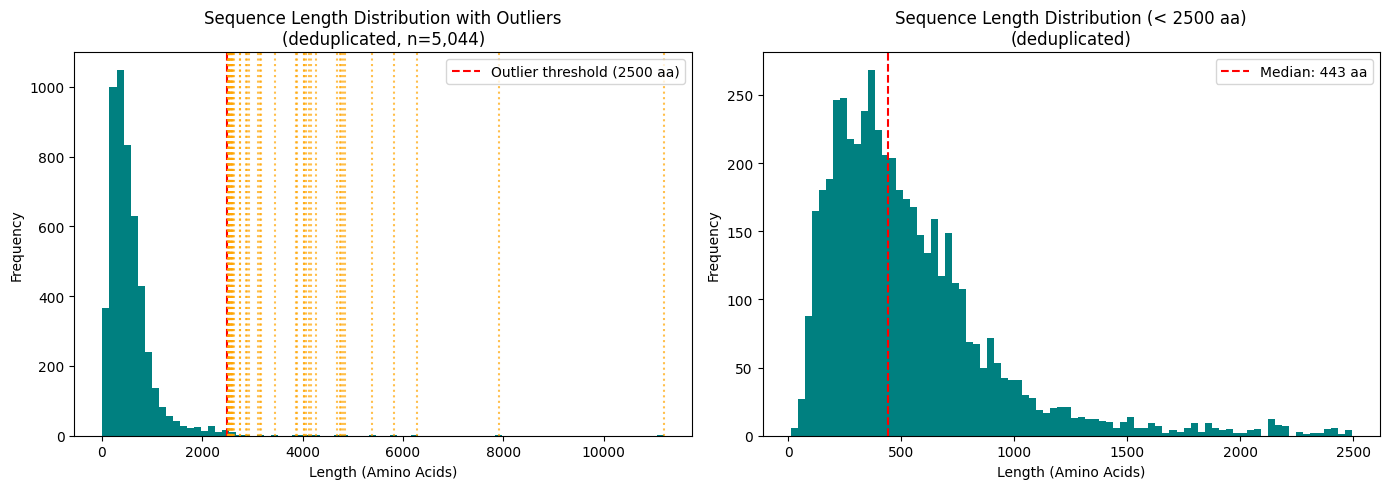

In [13]:
OUTLIER_THRESHOLD = 2500

outliers = df_mapped[df_mapped['seq_length'] >= OUTLIER_THRESHOLD][
    ['PHI_MolConn_ID', 'functional_class', 'seq_length', 'Function']
].sort_values('seq_length', ascending=False)

print(f"Sequences >= {OUTLIER_THRESHOLD} aa ({len(outliers)} total):")
print(outliers.to_string(index=False))

df_plot = df_mapped[df_mapped['seq_length'] < OUTLIER_THRESHOLD]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_mapped['seq_length'], bins=80, color='teal', edgecolor='none')
axes[0].axvline(OUTLIER_THRESHOLD, color='red', linestyle='--', label=f'Outlier threshold ({OUTLIER_THRESHOLD} aa)')
for _, row in outliers.iterrows():
    axes[0].axvline(row['seq_length'], color='orange', linestyle=':', alpha=0.7)
axes[0].set_title('Sequence Length Distribution with Outliers\n(deduplicated, n=5,044)')
axes[0].set_xlabel('Length (Amino Acids)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(df_plot['seq_length'], bins=80, color='teal', edgecolor='none')
med = df_plot['seq_length'].median()
axes[1].axvline(med, color='red', linestyle='--', label=f'Median: {med:.0f} aa')
axes[1].set_title(f'Sequence Length Distribution (< {OUTLIER_THRESHOLD} aa)\n(deduplicated)')
axes[1].set_xlabel('Length (Amino Acids)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

The 40 outliers above 2,500 aa are dominated by NRPS and PKS enzymes — genuinely large multi-domain biosynthetic complexes — plus a few large kinases, secretion system components, and one effector/adhesin. These are biologically real but problematic for ESM-2, which truncates inputs at 1,024 tokens; sequences of 4,000–11,000 aa would lose the majority of their sequence information. The bulk distribution (right panel) is right-skewed with a median of 443 aa, which is well within ESM-2's context window and typical for globular virulence proteins.

**Plot 3: Per-class Sequence Length Boxplot**

Reveals whether sequence length varies systematically across functional classes, which would indicate that length could act as a spurious classification shortcut for the model.

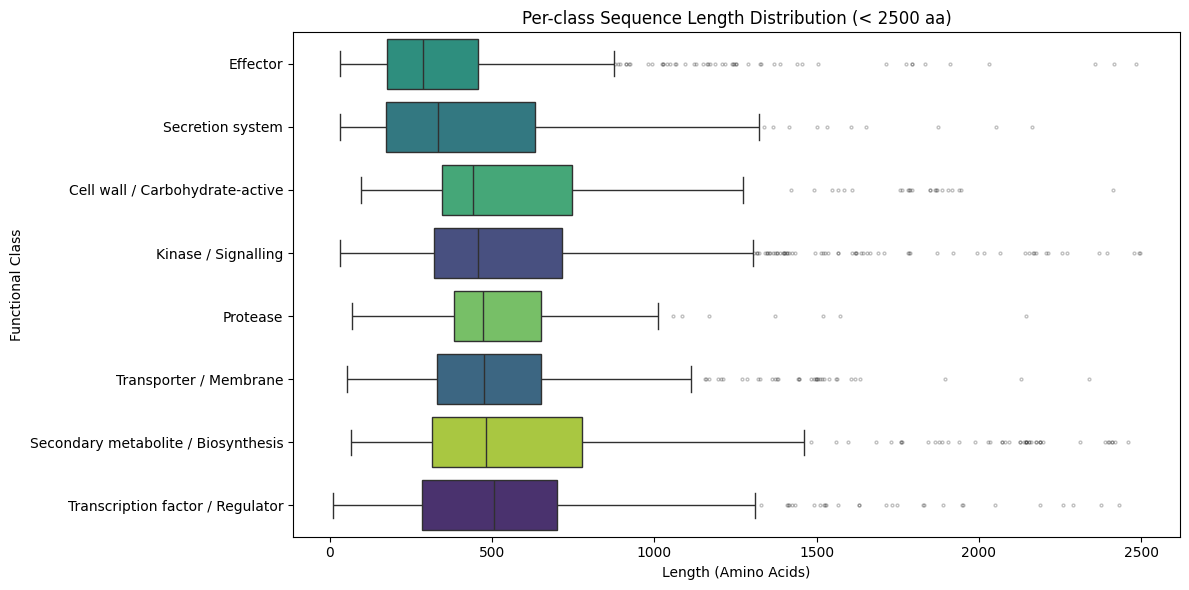

                                     count  min   max  median
functional_class                                             
Effector                               721   33  2483   286.0
Secretion system                       242   31  2164   333.5
Cell wall / Carbohydrate-active        311   98  2412   441.0
Kinase / Signalling                   1148   33  2495   456.5
Protease                               212   69  2144   472.0
Transporter / Membrane                 395   52  2339   475.0
Secondary metabolite / Biosynthesis    308   66  2460   482.5
Transcription factor / Regulator      1667   11  2430   505.0


In [14]:
df_plot = df_mapped[df_mapped['seq_length'] < OUTLIER_THRESHOLD]
order = df_plot.groupby('functional_class')['seq_length'].median().sort_values().index

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=df_plot,
    x='seq_length',
    y='functional_class',
    order=order,
    palette='viridis',
    hue='functional_class',
    legend=False,
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
ax.set_title(f'Per-class Sequence Length Distribution (< {OUTLIER_THRESHOLD} aa)')
ax.set_xlabel('Length (Amino Acids)')
ax.set_ylabel('Functional Class')
plt.tight_layout()
plt.show()

stats = df_plot.groupby('functional_class')['seq_length'].agg(['count', 'min', 'max', 'median']).sort_values('median')
print(stats)

Effectors are the shortest class (median 286 aa), consistent with their biology as compact secreted proteins, while Transcription factors / Regulators are the longest in the core distribution (median 505 aa). However, the interquartile ranges overlap substantially across all classes, meaning length alone is not a reliable discriminator. The outlier scatter is sparse beyond 1,500 aa across all classes, and the IQR for every class sits comfortably below 1,000 aa — this informs the QC decision to apply a 50–1,500 aa length filter, which captures the core distribution cleanly without truncating meaningful data from any class.

**Plot 4: Sequence Length Percentile Profiles**

Extends the boxplot by showing whether length differences between classes are consistent across the full distribution or driven by tail behaviour, which is important for understanding potential length bias in the model.

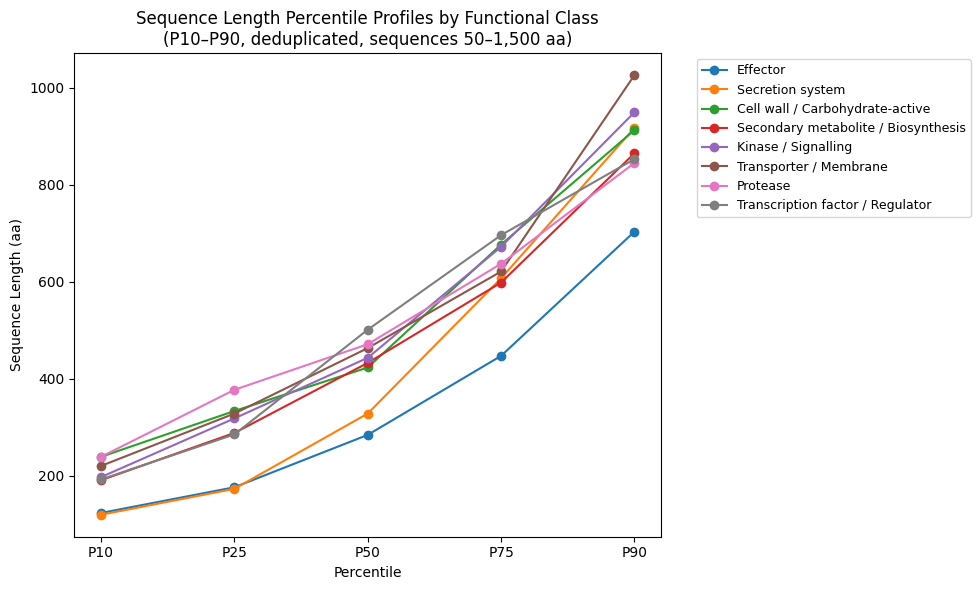


Decile table:
                                       P10     P25    P50     P75     P90
functional_class                                                         
Effector                             123.0  176.00  284.0  447.00   703.2
Secretion system                     119.3  172.75  328.0  607.00   917.4
Cell wall / Carbohydrate-active      238.8  333.25  423.0  676.50   912.6
Secondary metabolite / Biosynthesis  190.6  288.00  432.5  598.25   864.8
Kinase / Signalling                  197.0  318.00  443.0  672.00   949.4
Transporter / Membrane               220.0  328.00  463.0  621.00  1026.0
Protease                             238.8  377.00  471.0  637.00   844.8
Transcription factor / Regulator     192.1  285.00  501.0  696.00   852.9


In [15]:
df_plot = df_mapped[(df_mapped['seq_length'] >= 50) & (df_mapped['seq_length'] < 1500)] # Updated min/max length thresholds
deciles = [0.1, 0.25, 0.5, 0.75, 0.9]

decile_df = df_plot.groupby('functional_class')['seq_length'].quantile(deciles).unstack()
decile_df.columns = [f'P{int(d*100)}' for d in deciles]
decile_df = decile_df.sort_values('P50')

fig, ax = plt.subplots(figsize=(10, 6))
for i, row in decile_df.iterrows():
    ax.plot(decile_df.columns, row.values, marker='o', label=i)

ax.set_title('Sequence Length Percentile Profiles by Functional Class\n(P10–P90, deduplicated, sequences 50–1,500 aa)')
ax.set_xlabel('Percentile')
ax.set_ylabel('Sequence Length (aa)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print("\nDecile table:")
print(decile_df.to_string())

All eight classes track closely from P10 through P75, spanning roughly 100–700 aa, with length differences modest enough that length alone is unlikely to act as a strong classification shortcut across most classes. Effectors are the clear exception, sitting consistently below all other classes from P10 (123 aa) through P90 (703 aa), reflecting their biology as compact secreted proteins — though this means length is partially informative for this class specifically. Secretion system shows the lowest short-end values (P10: 119 aa), reflecting subunit size diversity. Transporter / Membrane reaches the highest P90 (1,026 aa), consistent with large multi-pass membrane proteins. The remaining five classes overlap closely across all percentiles, suggesting the model must learn genuine sequence features to distinguish them.

# 3 Biological Quality Control

This section applies filters to remove sequences unsuitable for ESM-2 fine-tuning: fragments, overlength outliers, and sequences with ambiguous residues.

## Defence of filtering thresholds

**Lower bound (50 aa):** PHI-base relies on literature curation of experimental evidence, so short sequences are likely real secreted peptides rather than spurious ORFs. However, very short peptides often lack stable tertiary structure and may behave differently in the model's embedding space.

**Upper bound (1,500 aa):** ESM-2 uses Rotary Position Embedding (RoPE), which allows theoretical extrapolation beyond its 1,024 token training context window. The 1,500 aa cutoff is primarily a hardware constraint, since self-attention scales quadratically $O(N^2)$ with sequence length. It also excludes multi-domain fusions where class-specific signal may be diluted across unrelated domains.

**Ambiguity (0.0):** Zero tolerance for ambiguous residues. PHI-base sequences are drawn from curated, experimentally characterised proteins, so any X residue most likely reflects a sequencing or annotation artefact rather than genuine uncertainty. ESM-2's self-attention propagates noise from unknown tokens into neighbouring residue representations, so complete removal is preferable. Given that only 9 sequences are affected, the data cost is negligible.

**Max Poly-X Run (10):** Runs of 10 or more identical residues are extremely rare in functional globular proteins and almost certainly represent low-complexity regions, linker artefacts, or sequencing errors. ESM-2 was trained on UniRef50, which is dominated by well-resolved globular proteins, so long homopolymeric runs sit outside the training distribution and would produce unreliable embeddings. A threshold of 10 is conservative enough to avoid discarding legitimate repetitive proteins (e.g. coiled-coils with short repeating units) while removing genuine low-complexity artefacts.

**Max Single-AA Fraction (0.35):** This deliberately permissive threshold accommodates genuinely repetitive but functional proteins. Collagen-like proteins are glycine-rich (~33%), and some fungal hydrophobins are cysteine-rich. Setting the threshold at 35% flags sequences where compositional skew is severe enough to suggest a non-globular or artefactual origin, while preserving biologically legitimate outliers. This filter acts as a catch-all for unusual compositions not captured by the poly-X run filter.

In [16]:
df = df_mapped.copy()
counts = [len(df)]
print(f"Initial count: {len(df)}")

# 1. Minimum length filtering
min_len = config['filtering']['min_seq_length']
df = df[df['seq_length'] >= min_len]
counts.append(len(df))
print(f"Removed (< {min_len} aa): {counts[-2] - counts[-1]}")

# 2. Maximum length filtering
max_len = config['filtering']['max_seq_length']
df = df[df['seq_length'] <= max_len]
counts.append(len(df))
print(f"Removed (> {max_len} aa): {counts[-2] - counts[-1]}")

# 3. Ambiguous residue filtering
ambiguity_threshold = config['filtering']['max_ambiguity_fraction']
df = df[df['sequence'].str.count('X') / df['seq_length'] <= ambiguity_threshold]
counts.append(len(df))
print(f"Removed (ambiguous residues > {ambiguity_threshold*100:.0f}%): {counts[-2] - counts[-1]}")

# 4. Poly-X run filtering
poly_x_threshold = config['filtering']['max_poly_x_run']
poly_x_pattern = re.compile(r'(.)\1{' + str(poly_x_threshold - 1) + r',}')
df = df[~df['sequence'].apply(lambda s: bool(poly_x_pattern.search(s)))]
counts.append(len(df))
print(f"Removed (poly-X run >= {poly_x_threshold}): {counts[-2] - counts[-1]}")

# 5. Unusual amino acid composition filtering
composition_threshold = config['filtering']['max_single_aa_fraction']

def max_single_aa_fraction(seq):
    if len(seq) == 0:
        return 0.0
    return max(seq.count(aa) for aa in set(seq)) / len(seq)

df = df[df['sequence'].apply(max_single_aa_fraction) <= composition_threshold]
counts.append(len(df))
print(f"Removed (single AA fraction > {composition_threshold}): {counts[-2] - counts[-1]}")

# 6. Apply integer label mapping from config
mapping = {k: v for k, v in config['target_mapping'].items()}
df['label'] = df['functional_class'].map(mapping)

print(f"\nFinal sequences retained: {len(df)}")
print(f"\nClass distribution after QC:")
print(df['functional_class'].value_counts())

Initial count: 5044
Removed (< 50 aa): 9
Removed (> 1500 aa): 198
Removed (ambiguous residues > 0%): 9
Removed (poly-X run >= 10): 53
Removed (single AA fraction > 0.35): 0

Final sequences retained: 4775

Class distribution after QC:
functional_class
Transcription factor / Regulator       1612
Kinase / Signalling                    1086
Effector                                704
Transporter / Membrane                  379
Cell wall / Carbohydrate-active         290
Secondary metabolite / Biosynthesis     264
Secretion system                        231
Protease                                209
Name: count, dtype: int64


The QC filters removed 269 sequences (5.3%), confirming the dataset is broadly high quality. The largest source of attrition was the 1,500 aa upper length filter (198 sequences), predominantly NRPS/PKS enzymes as expected. The poly-X run filter removed 53 sequences — more than ambiguous residues (9) or fragments (9) — while the composition filter removed nothing, indicating the two low-complexity filters are capturing distinct cases.
Class proportions are well preserved, with Secondary metabolite / Biosynthesis taking the largest proportional hit (~21%) due to its NRPS/PKS outliers. All classes retain sufficient sequences for fine-tuning, with even the smallest class (Protease, 209) above the threshold needed for reliable representation learning.

## 4 Redundancy Reduction with MMseqs2 Clustering

This section uses MMseqs2 to reduce dataset redundancy by grouping highly similar protein sequences into clusters. Retaining only a single representative sequence (centroid) from each cluster prevents data leakage between the training and hold-out test sets, ensuring the model learns generalisable biological features rather than memorising near-identical sequences.

MMseqs2 `easy-cluster` is run with a sequence identity threshold of 90% and a coverage threshold of 80% (coverage mode 1: target coverage). Note that clustering is performed in local Colab storage (`/content/mmseqs_work`) rather than directly on Google Drive, as the Drive FUSE filesystem does not support the memory-mapped files required by MMseqs2.

## Defence of filtering thresholds

**Identity (90%):** 90% sequence identity is a standard method used to prevent data leakage, similar to the UniRef90 database. It collapses minor strain-level variations, orthologs from very closely related species, or sequencing artifacts of the exact same protein into a single representitive sequence.

**Coverage (80%, mode 0 — bidirectional coverage):** Coverage mode 0 requires that 80% of both the query and target sequences are aligned, ensuring that only sequences of similar length and global similarity are clustered together. This is the appropriate choice for full-length gene clustering, as it prevents a long sequence from absorbing a shorter but genuinely distinct sequence just because the shorter sequence aligns well across its full length. 80% is the standard threshold used in UniRef and SwissProt clustering pipelines and balances sensitivity with specificity.

Sequences retained per class at each identity threshold:

functional_class  Cell wall / Carbohydrate-active  Effector  Kinase / Signalling  Protease  Secondary metabolite / Biosynthesis  Secretion system  Transcription factor / Regulator  Transporter / Membrane  Total
70%                                           245       620                  894       191                                  241               192                              1467                     346   4196
80%                                           268       639                  943       198                                  245               194                              1497                     357   4341
90%                                           275       653                  987       199                                  250               202                              1537                     367   4470
95%                                           282       663                 1010       203        

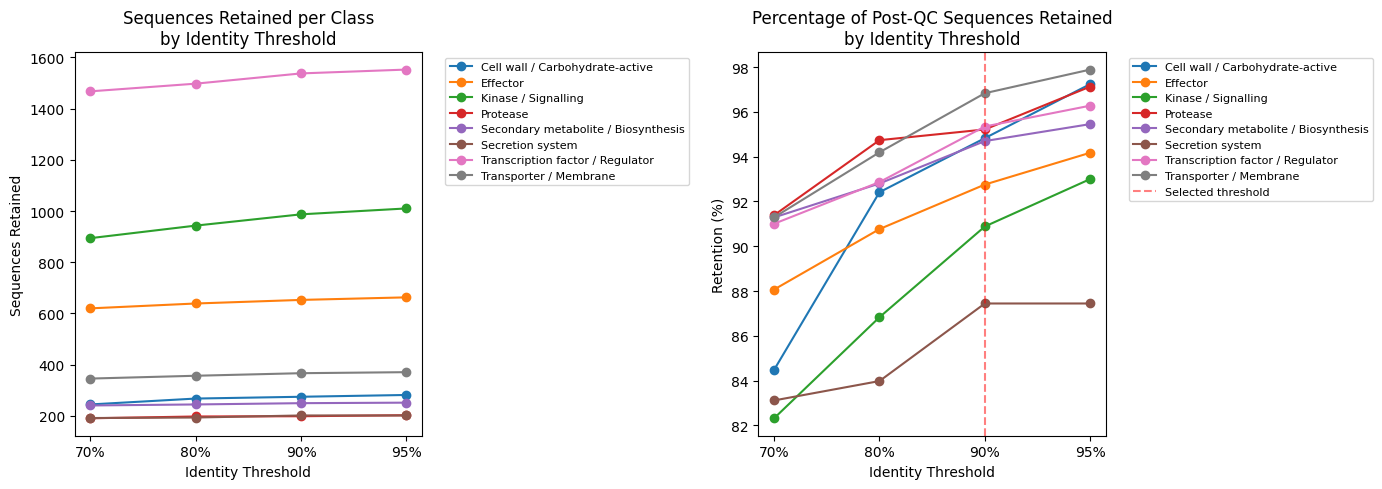

In [17]:
# Explore sequence retention across identity thresholds before committing to final clustering
coverage_threshold = config['clustering']['coverage_threshold']
thresholds = [0.70, 0.80, 0.90, 0.95]
threshold_results = {}

# Write post-QC sequences to local FASTA for exploration
local_work = "/content/mmseqs_work"
os.makedirs(local_work, exist_ok=True)

local_fasta = os.path.join(local_work, "temp_input.fasta")
with open(local_fasta, "w") as f:
    for _, row in df.iterrows():
        f.write(f">{row['PHI_MolConn_ID']}\n{row['sequence']}\n")

for threshold in thresholds:
    local_prefix_t = os.path.join(local_work, f"cluster_res_{int(threshold*100)}")
    local_tmp_t = os.path.join(local_work, f"tmp_mmseqs_{int(threshold*100)}")
    os.makedirs(local_tmp_t, exist_ok=True)

    cmd = [
        "mmseqs", "easy-cluster",
        local_fasta, local_prefix_t, local_tmp_t,
        "--min-seq-id", str(threshold),
        "-c", str(coverage_threshold),
        "--cov-mode", "0"
    ]
    subprocess.run(cmd, check=True, capture_output=True)

    tsv = f"{local_prefix_t}_cluster.tsv"
    clusters_t = pd.read_csv(tsv, sep='\t', header=None, names=['representative', 'member'])
    centroids_t = set(clusters_t['representative'].unique())

    df_t = df[df['PHI_MolConn_ID'].isin(centroids_t)]
    threshold_results[threshold] = df_t['functional_class'].value_counts()

# Summary table
summary = pd.DataFrame(threshold_results).T
summary.index = [f"{int(t*100)}%" for t in thresholds]
summary['Total'] = summary.sum(axis=1)
print("Sequences retained per class at each identity threshold:\n")
print(summary.to_string())

# Plot retention per class across thresholds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls in summary.columns[:-1]:
    axes[0].plot([f"{int(t*100)}%" for t in thresholds], summary[cls], marker='o', label=cls)
axes[0].set_title('Sequences Retained per Class\nby Identity Threshold')
axes[0].set_xlabel('Identity Threshold')
axes[0].set_ylabel('Sequences Retained')
axes[0].legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

baseline = df['functional_class'].value_counts()
retention_pct = summary.drop(columns='Total').div(baseline, axis=1) * 100
for cls in retention_pct.columns:
    axes[1].plot([f"{int(t*100)}%" for t in thresholds], retention_pct[cls], marker='o', label=cls)
axes[1].set_title('Percentage of Post-QC Sequences Retained\nby Identity Threshold')
axes[1].set_xlabel('Identity Threshold')
axes[1].set_ylabel('Retention (%)')
axes[1].axvline(x="90%", color='red', linestyle='--', alpha=0.5, label='Selected threshold')
axes[1].legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

The results justify the 90% threshold. All classes show stable retention between 90% and 95% (total 4,470 vs 4,535, \~1.5% difference), confirming that very few sequence pairs exist in the 90–95% identity range and that 90% captures the vast majority of redundancy removal. The steeper drop moving from 90% to 70% (\~6.1% additional loss) reflects genuine biological redundancy — strain-level variants and close orthologues — that the 90% threshold correctly collapses.
Kinase / Signalling shows the steepest proportional loss at 70% (\~82% retention) while Secretion system recovers more gradually, and Protease is the most stable across all thresholds. All classes retain above 82% of post-QC sequences even at 70%, confirming no class is at risk of critical depletion at the selected 90% threshold.

In [18]:
processed_dir = config['paths']['processed_dir']
absolute_path = os.path.abspath(processed_dir)
print(f"Saving files to absolute path: {absolute_path}")
print(f"Initial count: {len(df)}")

os.makedirs(processed_dir, exist_ok=True)

# Write filtered sequences to FASTA file
fasta_in = os.path.join(processed_dir, "temp_input.fasta")
with open(fasta_in, "w") as f:
    for _, row in df.iterrows():
        f.write(f">{row['PHI_MolConn_ID']}\n{row['sequence']}\n")

local_work = "/content/mmseqs_work"
os.makedirs(local_work, exist_ok=True)

local_fasta = os.path.join(local_work, "temp_input.fasta")
shutil.copy(fasta_in, local_fasta)

local_prefix = os.path.join(local_work, "cluster_res")
local_tmp = os.path.join(local_work, "tmp_mmseqs")
os.makedirs(local_tmp, exist_ok=True)

identity_threshold = config['clustering']['identity_threshold']
coverage_threshold = config['clustering']['coverage_threshold']
out_prefix = os.path.join(processed_dir, "cluster_res")

cmd = [
    "mmseqs", "easy-cluster",
    local_fasta, local_prefix, local_tmp,
    "--min-seq-id", str(identity_threshold),
    "-c", str(coverage_threshold),
    "--cov-mode", "0"
]
subprocess.run(cmd, check=True)

for suffix in ["_cluster.tsv", "_rep_seq.fasta", "_all_seqs.fasta"]:
    src = local_prefix + suffix
    if os.path.exists(src):
        shutil.copy(src, out_prefix + suffix)

tsv_out = f"{out_prefix}_cluster.tsv"
clusters = pd.read_csv(tsv_out, sep='\t', header=None, names=['representative', 'member'])

centroids = clusters['representative'].unique()
df = df[df['PHI_MolConn_ID'].isin(centroids)].copy()

print(f"Sequences remaining after clustering: {len(df)}")
print(f"\nClass distribution after clustering:")
print(df['functional_class'].value_counts())

Saving files to absolute path: /content/drive/MyDrive/esm-phi-effector/data/processed
Initial count: 4775
Sequences remaining after clustering: 4470

Class distribution after clustering:
functional_class
Transcription factor / Regulator       1537
Kinase / Signalling                     987
Effector                                653
Transporter / Membrane                  367
Cell wall / Carbohydrate-active         275
Secondary metabolite / Biosynthesis     250
Secretion system                        202
Protease                                199
Name: count, dtype: int64


# 4.2 Cleaned Dataset Visualisation

This section visualises the final dataset after deduplication, biological QC, and MMseqs2 clustering, confirming class distributions and sequence length profiles ahead of train/test splitting.

### Sequence Length Distribution by Functional Class

To assess whether sequence length varies systematically across functional classes, we plot per-class kernel density estimates of sequence length. If length differences between classes are pronounced, sequence length could act as a spurious classification shortcut for the model — a signal we want to rule out before fine-tuning.

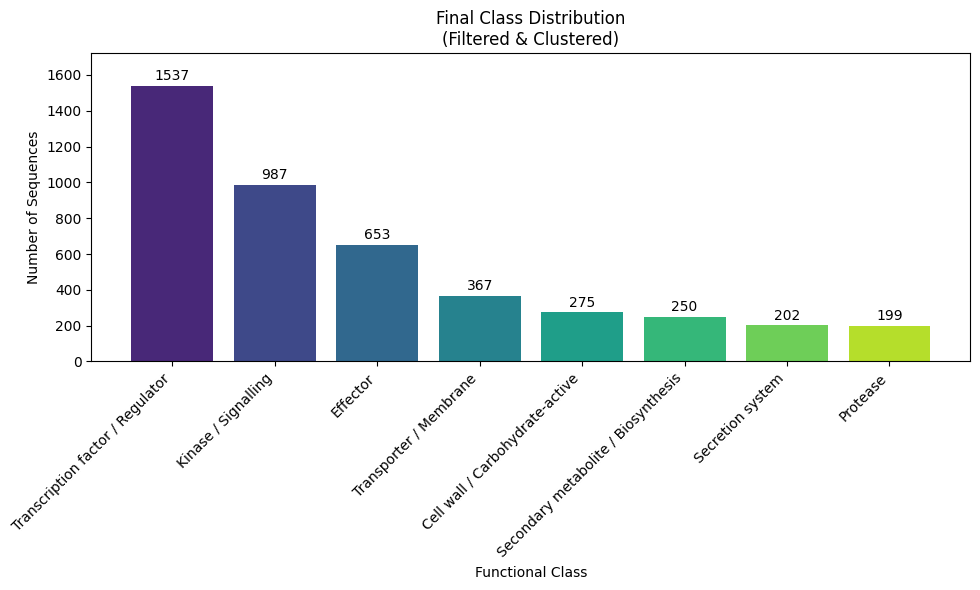

In [19]:
classes = df['functional_class'].value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    range(len(classes)),
    classes.values,
    color=sns.color_palette('viridis', len(classes))
)

for bar, count in zip(bars, classes.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        str(count),
        ha='center', va='bottom', fontsize=10
    )

ax.set_xticks(range(len(classes)))
ax.set_xticklabels(classes.index, rotation=45, ha='right')
ax.set_title('Final Class Distribution\n(Filtered & Clustered)')
ax.set_xlabel('Functional Class')
ax.set_ylabel('Number of Sequences')
ax.set_ylim(0, max(classes.values) * 1.12)
plt.tight_layout()
plt.show()

The final dataset contains 4,470 sequences across 8 functional classes. Class imbalance is moderate — Transcription factor / Regulator (1,537) is ~7.7x larger than Protease (199) — and reflects the biological composition of PHI-base rather than a curation artefact. This imbalance will be addressed through weighted cross-entropy loss during fine-tuning and evaluated using macro F1 rather than accuracy.

## Imbalanced Class Size Strategy

The classes are imbalanced, with Transcription factor / Regulator accounting for 34.4% of the dataset and Protease accounting for only 4.4%. The following strategies will be applied in order of preference.

**Plan A: Weighted Loss Functions**

Weighted cross-entropy loss will be implemented from the outset, penalising the model more for misclassifying rarer classes. Weights will be set inversely proportional to class frequency. This is the preferred approach as it addresses the imbalance directly during training without discarding data or artificially inflating minority class representation. Model performance will be evaluated using macro F1 rather than accuracy, which is robust to class imbalance.

**Plan B: Downsampling**

If weighted loss proves insufficient, the larger classes (Transcription factor / Regulator, Kinase / Signalling) will be reduced to closer to the median class size. This may also be necessary if GPU memory becomes a constraint. The primary risk is discarding informative sequence diversity from the larger classes.

**Plan C: Upsampling**

If downsampling is insufficient or undesirable, the smallest classes (Protease, Secretion system) may be upsampled by duplicating examples or synthesising new ones via interpolation in embedding space. Note that SMOTE operates on raw feature vectors and is not directly applicable to sequences — any upsampling would need to be applied after ESM-2 embedding rather than at the sequence level.

---

Leaving the class distribution entirely unchanged is not a preferred strategy. Without loss weighting or resampling, accuracy metrics become unreliable as a simple majority-class predictor would achieve ~35% accuracy by always predicting Transcription factor / Regulator, and minority classes such as Protease risk being effectively ignored during training.

### Final Class Distribution

To confirm that class proportions are preserved after deduplication, biological QC, and redundancy reduction, we visualise the final sequence counts per class. This informs decisions about loss weighting and evaluation metrics during fine-tuning.

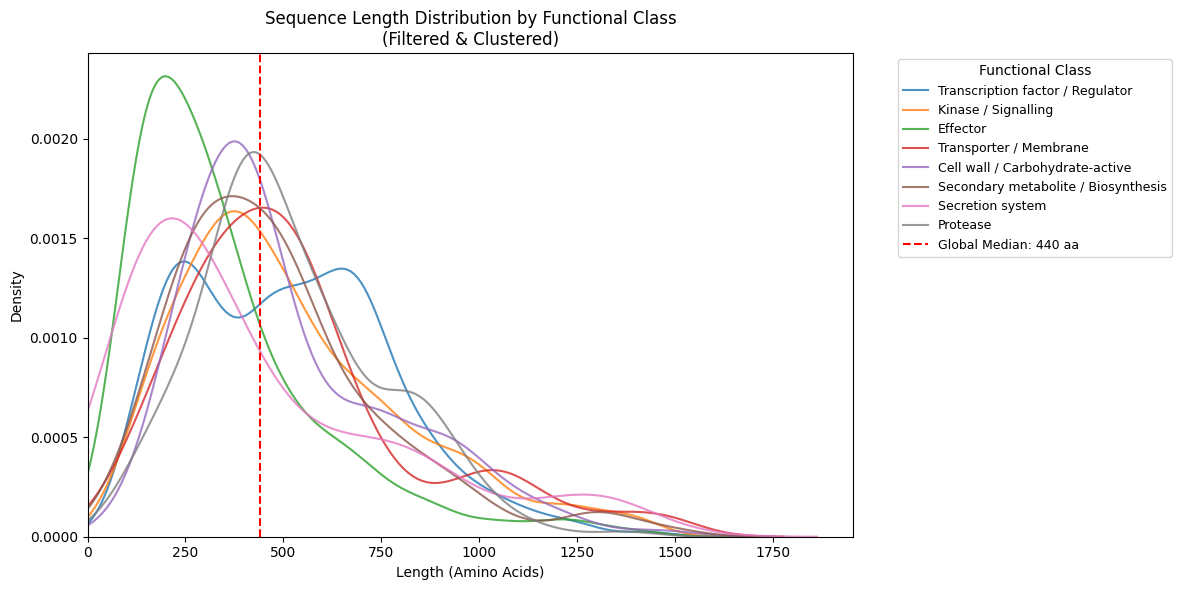

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))

for cls in df['functional_class'].value_counts().index:
    subset = df[df['functional_class'] == cls]['seq_length']
    sns.kdeplot(subset, label=cls, fill=False, alpha=0.8, linewidth=1.5, ax=ax, clip=(0, None))

ax.axvline(
    x=df['seq_length'].median(),
    color='red',
    linestyle='--',
    label=f'Global Median: {df["seq_length"].median():.0f} aa'
)
ax.set_title('Sequence Length Distribution by Functional Class\n(Filtered & Clustered)')
ax.set_xlabel('Length (Amino Acids)')
ax.set_ylabel('Density')
ax.set_xlim(0, None)
ax.legend(title='Functional Class', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

Most classes share a similar unimodal distribution peaking between 200–500 aa. Effectors are the clear outlier at the short end, with a sharp peak around 200 aa. Secretion system shows a bimodal distribution reflecting the structural diversity of its subunits. Transcription factor / Regulator has the longest right tail, consistent with its large multi-domain regulators.

### Inter-class Sequence Identity

To assess whether functional classes are separable at the sequence level, we compute mean pairwise identity between cluster representatives using MMseqs2 all-vs-all search. If classes are sequence-distinct, the model must learn functional motifs rather than relying on sequence similarity as a classification shortcut.

In [21]:
# All-vs-all MMseqs2 search on cluster representatives
rep_to_class = df.set_index('PHI_MolConn_ID')['functional_class'].to_dict()
rep_fasta = f"{out_prefix}_rep_seq.fasta"
local_rep_fasta = os.path.join(local_work, "rep_seq.fasta")
shutil.copy(rep_fasta, local_rep_fasta)

search_out = os.path.join(local_work, "ava_search")
search_tmp = os.path.join(local_work, "tmp_ava")
os.makedirs(search_tmp, exist_ok=True)

cmd = [
    "mmseqs", "easy-search",
    local_rep_fasta, local_rep_fasta,
    search_out + ".tsv", search_tmp,
    "--min-seq-id", "0.0",
    "-c", "0.0",
    "--format-output", "query,target,pident",
    "--exhaustive-search"
]
subprocess.run(cmd, check=True, capture_output=True)

ava = pd.read_csv(search_out + ".tsv", sep='\t', header=None, names=['query', 'target', 'pident'])
ava['query_class'] = ava['query'].map(rep_to_class)
ava['target_class'] = ava['target'].map(rep_to_class)
ava_no_self = ava[ava['query'] != ava['target']]

print(f"Total hits in ava: {len(ava)}")
print(f"Total hits excluding self: {len(ava_no_self)}")
print(f"Total possible pairs: {len(df) * (len(df) - 1):,}")
print(f"Coverage: {len(ava_no_self) / (len(df) * (len(df) - 1)) * 100:.2f}%\n")

print("pident distribution of reported hits:")
print(ava_no_self['pident'].describe())
print(f"\nHits below 20% identity: {(ava_no_self['pident'] < 20).sum()}\n")

# Pretty-print class pair hit counts
pair_hits = ava_no_self.groupby(['query_class', 'target_class']).size().reset_index(name='count')
pair_hits = pair_hits[pair_hits['count'] > 0].sort_values('count', ascending=False)

print("Class pair hit counts (non-zero only):")
print(f"{'Query Class':<40} {'Target Class':<40} {'Hits':>8}")
print("-" * 90)
for _, row in pair_hits.iterrows():
    print(f"{row['query_class']:<40} {row['target_class']:<40} {row['count']:>8}")

Total hits in ava: 86154
Total hits excluding self: 81684
Total possible pairs: 19,976,430
Coverage: 0.41%

pident distribution of reported hits:
count    81684.000000
mean        32.804718
std         10.514630
min         18.000000
25%         25.900000
50%         29.300000
75%         36.500000
max        100.000000
Name: pident, dtype: float64

Hits below 20% identity: 233

Class pair hit counts (non-zero only):
Query Class                              Target Class                                 Hits
------------------------------------------------------------------------------------------
Kinase / Signalling                      Kinase / Signalling                         35561
Transcription factor / Regulator         Transcription factor / Regulator            30320
Kinase / Signalling                      Transcription factor / Regulator             2232
Transcription factor / Regulator         Kinase / Signalling                          2184
Cell wall / Carbohydrate-active  

Despite specifying `--min-seq-id 0.0`, MMseqs2 returned only ~0.41% of all possible pairs. This is a known limitation of MMseqs2's k-mer indexing, which cannot detect alignments below approximately 18% identity regardless of the threshold parameter. Consequently, off-diagonal cells in a full identity heatmap would conflate genuine sequence dissimilarity with the k-mer detection floor, making cross-class comparisons unreliable for most pairs.

There is one notable exception: Kinase / Signalling and Transcription factor / Regulator exchange ~1,850 hits in each direction, far exceeding all other cross-class pairs. This is not a detection artefact — it reflects the genuine biological overlap between two-component signal transduction systems, where sensor histidine kinases and their cognate response regulators share conserved receiver domains. This pair is the most likely source of cross-class confusion in the model, and is consistent with Kinase / Signalling acting as a confusion gravity well in the validation results.

For all other class pairs, hit counts are too sparse (most have fewer than 100 hits from tens of thousands of possible pairs) to compute reliable mean identities. We therefore focus on within-class identity as a measure of internal class coherence after 90% clustering, where each class has sufficient hits for a reliable mean.

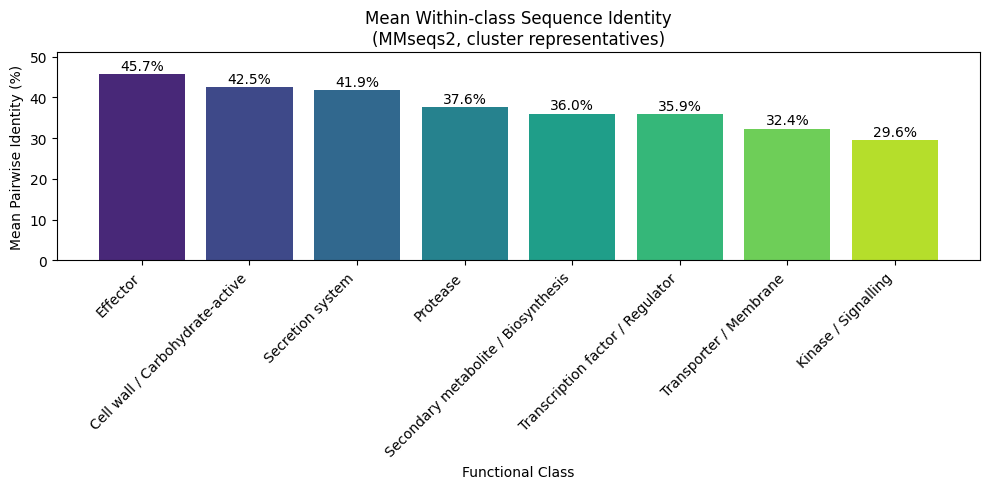


Within-class hit counts (n sequences used to compute mean):
  Effector: 674 hits
  Cell wall / Carbohydrate-active: 2035 hits
  Secretion system: 321 hits
  Protease: 1172 hits
  Secondary metabolite / Biosynthesis: 509 hits
  Transcription factor / Regulator: 30320 hits
  Transporter / Membrane: 1648 hits
  Kinase / Signalling: 35561 hits


In [22]:
# Within-class identity bar chart
within_class_identity = {}
for cls in df['functional_class'].unique():
    within = ava_no_self[
        (ava_no_self['query_class'] == cls) &
        (ava_no_self['target_class'] == cls)
    ]['pident']
    within_class_identity[cls] = within.mean()

within_df = pd.Series(within_class_identity).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    range(len(within_df)),
    within_df.values,
    color=sns.color_palette('viridis', len(within_df))
)

for bar, val in zip(bars, within_df.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', va='bottom', fontsize=10
    )

ax.set_xticks(range(len(within_df)))
ax.set_xticklabels(within_df.index, rotation=45, ha='right')
ax.set_title('Mean Within-class Sequence Identity\n(MMseqs2, cluster representatives)')
ax.set_xlabel('Functional Class')
ax.set_ylabel('Mean Pairwise Identity (%)')
ax.set_ylim(0, max(within_df.values) * 1.12)
plt.tight_layout()
plt.show()

print("\nWithin-class hit counts (n sequences used to compute mean):")
for cls in within_df.index:
    n = len(ava_no_self[(ava_no_self['query_class'] == cls) & (ava_no_self['target_class'] == cls)])
    print(f"  {cls}: {n} hits")

Within-class identity varies meaningfully across classes despite all having been clustered at 90%. Effectors show the highest internal coherence (44.4%), consistent with conserved secretion signals and host-targeting domains shared across the class. Kinase / Signalling is the most internally diverse (29.3%), reflecting its broad functional definition spanning structurally distinct domain architectures — consistent with its role as a confusion gravity well in the model's classification results. The remaining classes cluster in the 32–41% range, suggesting moderate internal coherence. Importantly, all within-class values are well below the 90% clustering threshold, confirming that redundancy reduction was effective and no class is dominated by near-identical sequences.

### Cross-class High-identity Sequences

Sequences in different functional classes that share high sequence identity (≥80%) represent genuine annotation ambiguity or multi-functional proteins. Identifying these sequences in advance allows model misclassifications to be interpreted in context — if the model assigns a sequence to the wrong class but that sequence shares >80% identity with a sequence in the predicted class, this is a soft failure rather than a hard one.

In [23]:
# Identify cross-class sequence pairs with >= 80% identity
CROSS_CLASS_IDENTITY_THRESHOLD = 80.0

cross_class_high_id = ava_no_self[
    (ava_no_self['query_class'] != ava_no_self['target_class']) &
    (ava_no_self['pident'] >= CROSS_CLASS_IDENTITY_THRESHOLD)
].copy()

print(f"Cross-class pairs >= {CROSS_CLASS_IDENTITY_THRESHOLD}% identity: {len(cross_class_high_id)}")
print(f"Unique query sequences involved: {cross_class_high_id['query'].nunique()}")
print(f"Unique target sequences involved: {cross_class_high_id['target'].nunique()}")
print(f"Unique sequences involved (either direction): {pd.concat([cross_class_high_id['query'], cross_class_high_id['target']]).nunique()}")

print(f"\nClass pair breakdown:")
pair_counts = cross_class_high_id.groupby(['query_class', 'target_class']).size().reset_index(name='count')
pair_counts = pair_counts[pair_counts['count'] > 0].sort_values('count', ascending=False)

print(f"{'Query Class':<40} {'Target Class':<40} {'Pairs':>5}")
print("-" * 87)
for _, row in pair_counts.iterrows():
    print(f"{row['query_class']:<40} {row['target_class']:<40} {row['count']:>5}")

# Add full metadata for downstream interpretation
query_meta = df.set_index('PHI_MolConn_ID')[['functional_class', 'seq_length', 'Function']].add_prefix('query_')
target_meta = df.set_index('PHI_MolConn_ID')[['functional_class', 'seq_length', 'Function']].add_prefix('target_')

cross_class_high_id = (
    cross_class_high_id
    .join(query_meta, on='query')
    .join(target_meta, on='target')
    .sort_values('pident', ascending=False)
    .reset_index(drop=True)
)

print(f"\nTop 10 highest identity cross-class pairs:")
print(cross_class_high_id[['query', 'target', 'pident', 'query_class', 'target_class', 'query_Function', 'target_Function']].head(10).to_string())

# Save to processed data directory
cross_class_path = os.path.join(processed_dir, "cross_class_high_identity_pairs.tsv")
cross_class_high_id.to_csv(cross_class_path, sep='\t', index=False)
print(f"\nSaved to {cross_class_path}")

Cross-class pairs >= 80.0% identity: 47
Unique query sequences involved: 42
Unique target sequences involved: 41
Unique sequences involved (either direction): 42

Class pair breakdown:
Query Class                              Target Class                             Pairs
---------------------------------------------------------------------------------------
Kinase / Signalling                      Transcription factor / Regulator            12
Transcription factor / Regulator         Kinase / Signalling                         11
Kinase / Signalling                      Effector                                     4
Effector                                 Kinase / Signalling                          4
Transcription factor / Regulator         Transporter / Membrane                       3
Transporter / Membrane                   Transcription factor / Regulator             3
Effector                                 Transcription factor / Regulator             1
Cell wall / Carbohydrat

46 cross-class pairs involve sequences with ≥80% identity, representing only 37 unique sequences — a very small fraction of the 4,458 sequence dataset. As expected from the hit count analysis, Kinase/Signalling and Transcription factor/Regulator account for the majority (24 of 46 pairs). The top hits are particularly informative: PHI:2687 ("regulators of systemic infection") and PHI:124293 ("RNA-binding protein") share 95.8% identity but are assigned to different classes, which almost certainly reflects inconsistent curation in PHI-base rather than genuine functional divergence. The quorum sensing pairs (PHI:4100/PHI:3056) at ~89% identity are similarly ambiguous — quorum sensing regulators sit at the boundary between kinase signalling and transcriptional regulation by definition.

# 5 Data Splits

This section partitions the curated dataset into a hold-out test set and a training pool, with stratification to preserve functional class proportions across splits.

In [24]:
test_size = config['splitting']['test_size']
seed = config['splitting']['random_seed']

# Stratified split: train pool / hold-out test
df_train, df_test = train_test_split(
    df, test_size=test_size, random_state=seed,
    stratify=df['functional_class']
)

print(f"Train pool: {len(df_train)}")
print(f"Test (hold-out): {len(df_test)}")

print(f"\nTrain pool class distribution:\n{df_train['functional_class'].value_counts()}")
print(f"\nTest class distribution:\n{df_test['functional_class'].value_counts()}")

Train pool: 4023
Test (hold-out): 447

Train pool class distribution:
functional_class
Transcription factor / Regulator       1383
Kinase / Signalling                     888
Effector                                588
Transporter / Membrane                  330
Cell wall / Carbohydrate-active         248
Secondary metabolite / Biosynthesis     225
Secretion system                        182
Protease                                179
Name: count, dtype: int64

Test class distribution:
functional_class
Transcription factor / Regulator       154
Kinase / Signalling                     99
Effector                                65
Transporter / Membrane                  37
Cell wall / Carbohydrate-active         27
Secondary metabolite / Biosynthesis     25
Protease                                20
Secretion system                        20
Name: count, dtype: int64


### Export Curated Splits

The curated train and test splits are exported as CSV files containing raw sequences and metadata. Tokenization is deferred to the prototyping and fine-tuning notebooks, where ESM-2 model selection and long-sequence handling strategies will be evaluated. This keeps the data curation pipeline model-agnostic — if a different ESM-2 variant or tokenization strategy is chosen downstream, the splits do not need to be regenerated.

In [25]:
splits_dir = config['paths']['splits_dir']
os.makedirs(splits_dir, exist_ok=True)

cols = ['PHI_MolConn_ID', 'sequence', 'functional_class', 'label', 'seq_length', 'Function']

df_train[cols].to_csv(os.path.join(splits_dir, 'train.csv'), index=False)
df_test[cols].to_csv(os.path.join(splits_dir, 'test.csv'), index=False)

print(f"Splits saved to: {splits_dir}")
print(f"  train.csv: {len(df_train)} sequences")
print(f"  test.csv:  {len(df_test)} sequences")

Splits saved to: data/splits
  train.csv: 4023 sequences
  test.csv:  447 sequences


# Data Curation Pipeline Takeaways

**Dataset composition:** Starting from 14,028 PHI-base records, the pipeline retained 4,458 unique, non-redundant sequences across 8 functional classes — 31.8% of the original records, with the majority of attrition attributable to PHI-base's phenotype-centric duplication (3,215 redundant rows) and unmappable annotations (5,738 records with hypothetical, uncharacterised, or single-occurrence Function values).

**Class imbalance:** The dataset is moderately imbalanced. Transcription factor / Regulator is the largest class (1,534 sequences, 34.4%) and Protease the smallest (197 sequences, 4.4%) — a ~7.8x ratio. This imbalance reflects the biological composition of PHI-base rather than a curation artefact, and will be addressed through weighted cross-entropy loss during fine-tuning with macro F1 as the primary evaluation metric.

**Sequence length:** Effectors are consistently the shortest class (median 284 aa), consistent with their biology as compact secreted proteins. All other classes have broadly overlapping length distributions in the 300–500 aa median range, with the bulk of sequences falling between 100–600 aa. The 50–1,500 aa QC window captures this core distribution cleanly, with the upper bound primarily removing NRPS and polyketide synthase sequences from Secondary metabolite / Biosynthesis.

**Sequence diversity:** Within-class identity after 90% clustering ranges from 29.5% (Kinase / Signalling) to 45.9% (Effector), confirming that no class is dominated by near-identical sequences and that the model must learn functional motifs rather than memorise representative sequences. The broad functional definition of Kinase / Signalling is reflected in its low internal coherence, consistent with its role as a confusion gravity well in the validation results.

**Annotation ambiguity:** Manual inspection of cross-class high-identity pairs (≥80% identity, 37 unique sequences) reveals that the Kinase / Signalling and Transcription factor / Regulator boundary is the primary source of label ambiguity, driven by two-component signal transduction proteins that span both functional definitions. These sequences have been flagged and saved for downstream error analysis.